In [3]:
! pip install numpy
! pip install matplotlib
! pip install pillow

In [4]:
"""
This assignment further investigates the SVD for image analysis. This also shows you how to plot using matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
# ----------------------------
# Load the images
# ----------------------------

# You may change the input file here
fname = "mnist_4/img_"

# Declare and initialize tensor for storage: 28 x 28 x 12
digits = np.zeros((28, 28, 12))

for i in range(1, 13):  
    fname_load = f"{fname}{i}.jpg"
    img = Image.open(fname_load).convert("L")  # grayscale
    digits[:, :, i-1] = np.array(img)


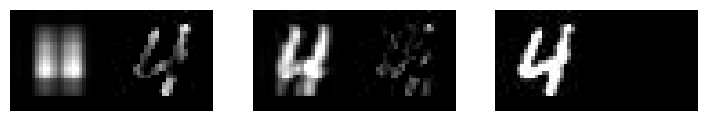

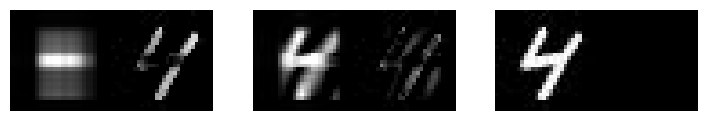

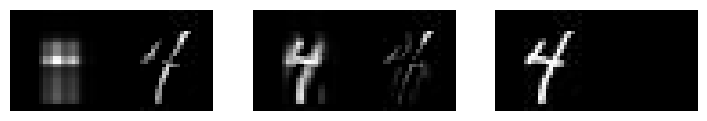

In [ ]:

# ----------------------------
# Explore SVD reconstructions
# ----------------------------

# Number of SVD components to use (try changing this)
# the max number of components is 28
num_comp = [1, 3, 28]

# Loop over images (currently only the first one, like MATLAB code)
for i in range(len(num_comp)):  # change to range(12) to loop over all images
    curr_img = digits[:, :, i]

    # Compute the SVD
    U, S, Vt = np.linalg.svd(curr_img, full_matrices=True)
    plt.figure(figsize=(12,8))
    for j, k in enumerate(num_comp):
        
        plt.subplot(4, 4, j + 1)

        # Reconstruct image using k components
        img_recon = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
        img_error = curr_img - img_recon

        # Display reconstructed image and error side by side
        combined = np.hstack((img_recon, img_error))
        plt.imshow(combined, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
    plt.show()